In [1]:
from PIL import Image
import numpy as np
import os
import sys

sys.path.append("/home/alberto/UnReflectAnything/")
from utilities.visualization import rgb, panelize
import torch
from dataset.rgbp import HOUSECAT6D_Dataset
from rich import print
%load_ext autoreload
%autoreload 2    


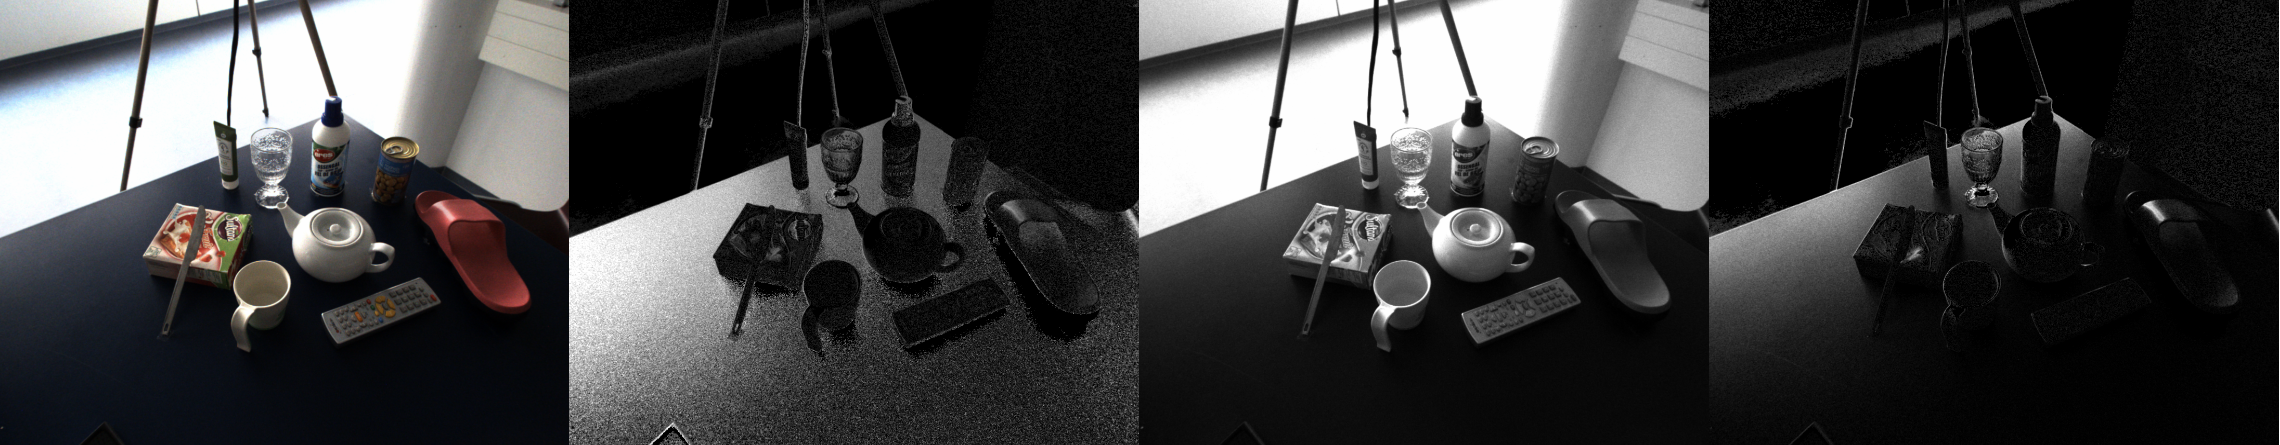

In [2]:
dataset = HOUSECAT6D_Dataset(
    root_dir="/datasets/HouseCat6D/",
    # scene_names=["scene01"],
    rho_s=0.6,
    eps=1e-8,
)

# Create dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
idataloade = iter(dataloader)

# Test loading a batch
for b, batch in enumerate(dataloader):
    break
rgb(
    panelize(
        rgb(batch["rgb"][0], as_tensor=True, resize=(892//2, 1140//2), colormap="gray"),
        rgb(batch["DoP"][0], as_tensor=True, resize=(892//2, 1140//2), colormap="gray"),
        rgb(batch["S0"][0], as_tensor=True, resize=(892//2, 1140//2), colormap="gray"),
        rgb(batch["S0"][0]*batch["DoP"][0], as_tensor=True, resize=(892//2, 1140//2), colormap="gray"),
    )
)

In [3]:
from transformers import pipeline
from PIL import Image
import requests

# load pipe
depth_estimator = pipeline(task="depth-estimation", model="Intel/dpt-hybrid-midas")

# load image
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)

# inference

# depth = outputs.depth


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


In [4]:
batch["rgb"][0].shape

torch.Size([3, 852, 1096])

In [5]:
# Convert tensor from [3, H, W] to [H, W, 3] format and create PIL image
img_tensor = batch["rgb"][0].cpu()  # Shape: [3, 852, 1096]
img_numpy = img_tensor.permute(1, 2, 0).numpy()  # Shape: [852, 1096, 3]
# Ensure values are in [0, 255] range for PIL
img_numpy = (img_numpy * 255).astype('uint8') if img_numpy.max() <= 1.0 else img_numpy.astype('uint8')
img_pil = Image.fromarray(img_numpy)
outputs = depth_estimator(img_pil)

In [6]:
def depth_to_normal_map(depth_map, focal_length=1.0, baseline=1.0):
    """
    Convert a depth map to a normal map using gradient-based surface normal estimation.
    
    Args:
        depth_map: torch.Tensor of shape (B, 1, H, W) or (H, W) - input depth map
        focal_length: float - camera focal length (affects perspective correction)
        baseline: float - scaling factor for depth values
        
    Returns:
        normal_map: torch.Tensor of shape (B, 3, H, W) or (3, H, W) - RGB normal map
                   where R=x, G=y, B=z components of surface normals
    """
    
    # Handle different input shapes
    original_shape = depth_map.shape
    if len(depth_map.shape) == 2:  # (H, W)
        depth_map = depth_map.unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
        squeeze_output = True
    elif len(depth_map.shape) == 3:  # (1, H, W) or (C, H, W)
        if depth_map.shape[0] == 1:
            depth_map = depth_map.unsqueeze(0)  # (1, 1, H, W)
        else:
            depth_map = depth_map.unsqueeze(1)  # (B, 1, H, W)
        squeeze_output = True
    else:  # (B, C, H, W)
        squeeze_output = False
    
    B, C, H, W = depth_map.shape
    
    # Move to GPU if available
    device = depth_map.device
    
    # Create coordinate grids - shape: (H, W)
    y_coords, x_coords = torch.meshgrid(
        torch.arange(H, dtype=torch.float32, device=device),
        torch.arange(W, dtype=torch.float32, device=device),
        indexing='ij'
    )
    
    # Center coordinates around image center
    x_coords = x_coords - W / 2.0  # (H, W)
    y_coords = y_coords - H / 2.0  # (H, W)
    
    # Expand to batch dimensions
    x_coords = x_coords.unsqueeze(0).unsqueeze(0).expand(B, 1, -1, -1)  # (B, 1, H, W)
    y_coords = y_coords.unsqueeze(0).unsqueeze(0).expand(B, 1, -1, -1)  # (B, 1, H, W)
    
    # Convert depth map to 3D points in camera coordinates
    # Using perspective projection: X = (x * Z) / f, Y = (y * Z) / f
    Z = depth_map * baseline  # (B, 1, H, W)
    X = (x_coords * Z) / focal_length  # (B, 1, H, W)
    Y = (y_coords * Z) / focal_length  # (B, 1, H, W)
    
    # Compute gradients using Sobel filters for better edge handling
    sobel_x = torch.tensor([[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]], 
                          dtype=torch.float32, device=device).unsqueeze(0)  # (1, 1, 3, 3)
    sobel_y = torch.tensor([[[-1, -2, -1], [0, 0, 0], [1, 2, 1]]], 
                          dtype=torch.float32, device=device).unsqueeze(0)  # (1, 1, 3, 3)
    
    # Compute gradients for X, Y, Z coordinates
    dX_dx = F.conv2d(X, sobel_x, padding=1)  # (B, 1, H, W)
    dX_dy = F.conv2d(X, sobel_y, padding=1)  # (B, 1, H, W)
    
    dY_dx = F.conv2d(Y, sobel_x, padding=1)  # (B, 1, H, W)
    dY_dy = F.conv2d(Y, sobel_y, padding=1)  # (B, 1, H, W)
    
    dZ_dx = F.conv2d(Z, sobel_x, padding=1)  # (B, 1, H, W)
    dZ_dy = F.conv2d(Z, sobel_y, padding=1)  # (B, 1, H, W)
    
    # Compute surface tangent vectors
    # Tangent in x direction: T1 = (dX/dx, dY/dx, dZ/dx)
    T1 = torch.cat([dX_dx, dY_dx, dZ_dx], dim=1)  # (B, 3, H, W)
    
    # Tangent in y direction: T2 = (dX/dy, dY/dy, dZ/dy)  
    T2 = torch.cat([dX_dy, dY_dy, dZ_dy], dim=1)  # (B, 3, H, W)
    
    # Compute surface normal as cross product: N = T1 × T2
    # Cross product in vectorized form
    normal_x = T1[:, 1:2] * T2[:, 2:3] - T1[:, 2:3] * T2[:, 1:2]  # (B, 1, H, W)
    normal_y = T1[:, 2:3] * T2[:, 0:1] - T1[:, 0:1] * T2[:, 2:3]  # (B, 1, H, W)
    normal_z = T1[:, 0:1] * T2[:, 1:2] - T1[:, 1:2] * T2[:, 0:1]  # (B, 1, H, W)
    
    # Combine normal components
    normals = torch.cat([normal_x, normal_y, normal_z], dim=1)  # (B, 3, H, W)
    
    # Normalize to unit vectors
    norm = torch.sqrt(torch.sum(normals**2, dim=1, keepdim=True) + 1e-8)  # (B, 1, H, W)
    normals = normals / norm  # (B, 3, H, W)
    
    # Convert to normal map format (0-1 range, flipped Z for standard normal map convention)
    normal_map = torch.stack([
        (normals[:, 0] + 1.0) * 0.5,     # X: Red channel
        (-normals[:, 1] + 1.0) * 0.5,    # Y: Green channel (flipped)
        (normals[:, 2] + 1.0) * 0.5      # Z: Blue channel
    ], dim=1)  # (B, 3, H, W)
    
    # Handle output shape
    if squeeze_output:
        if len(original_shape) == 2:
            normal_map = normal_map.squeeze(0)  # (3, H, W)
        else:
            normal_map = normal_map.squeeze(0)  # (3, H, W)
    
    return normal_map


Time taken: 0.08564472198486328 seconds

Time taken: 0.05453610420227051 seconds

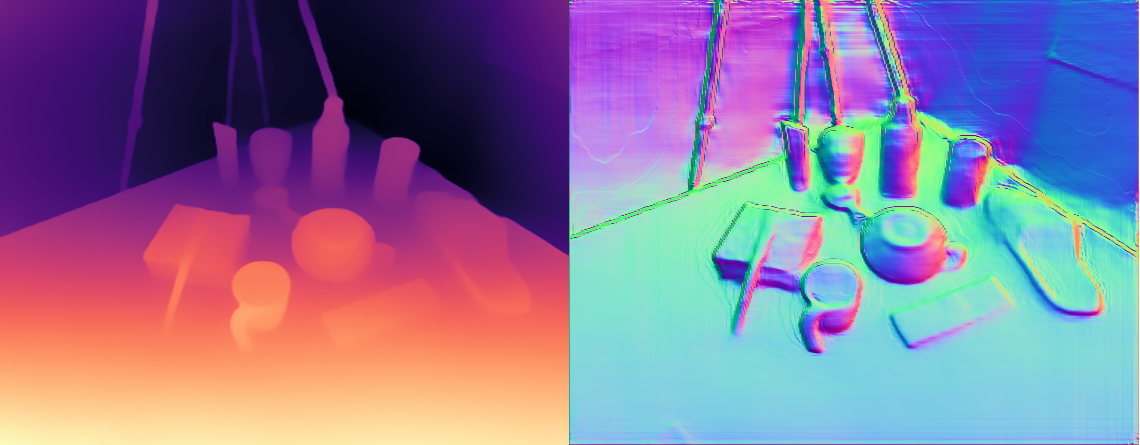

In [7]:
import time
import torch.nn.functional as F
start_time = time.time()
img_tensor = batch["rgb"][0].cpu()  # Shape: [3, 852, 1096]
img_numpy = img_tensor.permute(1, 2, 0).numpy()  # Shape: [852, 1096, 3]
# Ensure values are in [0, 255] range for PIL
img_numpy = (
    (img_numpy * 255).astype("uint8")
    if img_numpy.max() <= 1.0
    else img_numpy.astype("uint8")
)
img_pil = Image.fromarray(img_numpy)
outputs = depth_estimator(img_pil)
print(f"Time taken: {time.time() - start_time} seconds")
start_time = time.time()
normal_map = depth_to_normal_map(
    outputs["predicted_depth"], focal_length=1000.0
)  # (3, H, W)
print(f"Time taken: {time.time() - start_time} seconds")
rgb(
    panelize(
        rgb(
            outputs["predicted_depth"],
            as_tensor=True,
            resize=(892 // 2, 1140 // 2),
            colormap="magma",
        ),
        rgb(normal_map, as_tensor=True, resize=(892 // 2, 1140 // 2), colormap="hsv"),
    )
)

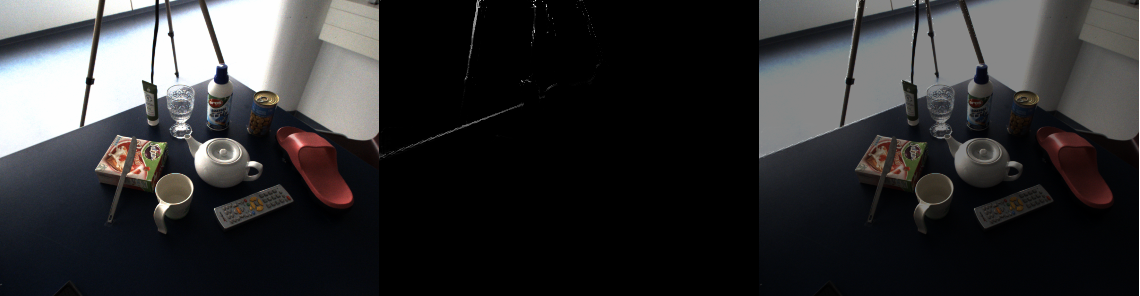

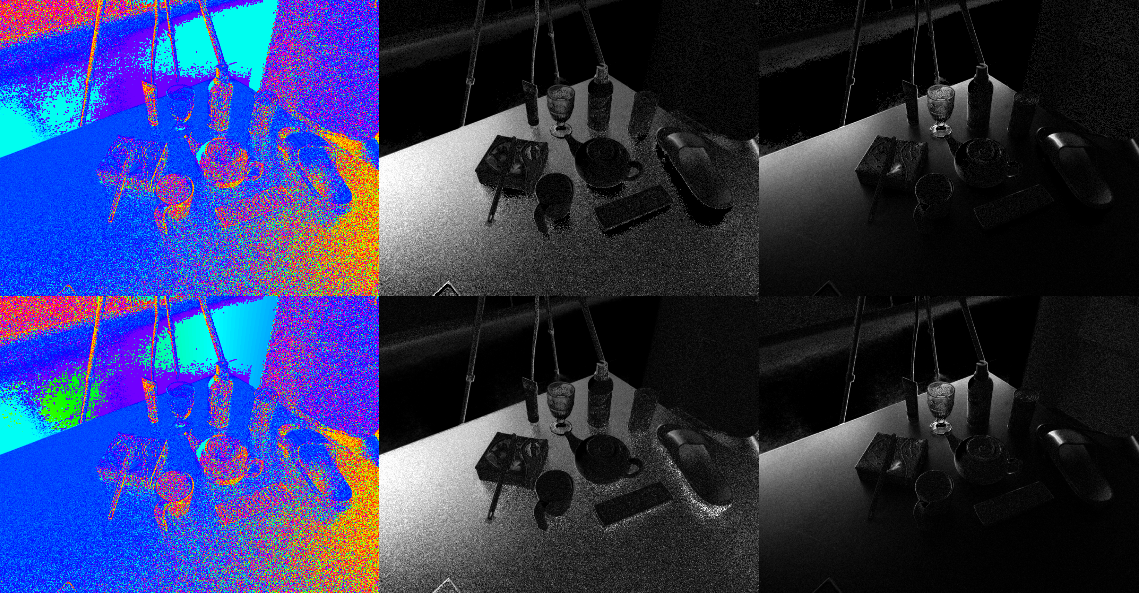

In [11]:
import torch
import torch.nn.functional as F
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------
# Helpers
# ---------------------------


def make_pixel_grid(B, H, W, device):
    """Return homogeneous pixel grid [B,3,H,W] with x,y in pixels, 1's row."""
    ys, xs = torch.meshgrid(
        torch.arange(H, device=device), torch.arange(W, device=device), indexing="ij"
    )
    ones = torch.ones_like(xs, dtype=torch.float32)
    pix = torch.stack([xs.float(), ys.float(), ones], dim=0)  # [3,H,W]
    return pix.unsqueeze(0).repeat(B, 1, 1, 1)  # [B,3,H,W]


def backproject_depth(depth, K):
    """
    Backproject to 3D camera coordinates.
    depth: [B,1,H,W] (meters)
    K:     [B,3,3] intrinsics
    Returns P_cam: [B,3,H,W]
    """
    B, _, H, W = depth.shape
    grid = make_pixel_grid(B, H, W, depth.device)  # [B,3,H,W]
    Kinv = torch.inverse(K)  # [B,3,3]
    rays = (Kinv @ grid.flatten(2)).view(B, 3, H, W)  # [B,3,H,W]
    # Camera looks along +Z; 3D point = ray * depth
    P = rays * depth  # [B,3,H,W]
    return P


def normalize(v, eps=1e-8):
    return v / (v.norm(dim=1, keepdim=True).clamp_min(eps))


def sample_random_light(B, radius_range=(0.5, 2.0), z_range=(0.5, 2.0), device="cuda"):
    """
    Sample point lights in camera coords (x,y within sphere shell, z forward).
    Returns L: [B,3] (camera space).
    """
    rmin, rmax = radius_range
    # sample x,y from a disk, z from z_range
    theta = torch.rand(B, device=device) * 2 * math.pi
    r = torch.sqrt(torch.rand(B, device=device)) * rmax
    r = (r - 0) / (rmax - 0) * (rmax - rmin) + rmin  # push away from center
    x = r * torch.cos(theta)
    y = r * torch.sin(theta)
    z = torch.rand(B, device=device) * (z_range[1] - z_range[0]) + z_range[0]
    L = torch.stack([x, y, z], dim=-1)  # [B,3]
    return L


def fresnel_gamma(theta, n_rel=1.5, eps=1e-8):
    """
    Intrinsic DoLP of specular for unpolarized incident light at incidence theta.
    gamma = |Rs - Rp| / (Rs + Rp), with Snell.
    theta: [B,1,H,W] radians, n_rel: n2/n1.
    Returns gamma in [0,1], shape [B,1,H,W].
    """
    n1 = 1.0
    n2 = n_rel
    sin_t = (n1 / n2) * torch.sin(theta).clamp(-1 + 1e-7, 1 - 1e-7)
    theta_t = torch.asin(sin_t)
    cos_t = torch.cos(theta)
    cos_tt = torch.cos(theta_t)

    # Fresnel reflectances for s (perp) and p (parallel)
    Rs_num = n2 * cos_t - n1 * cos_tt
    Rs_den = n2 * cos_t + n1 * cos_tt
    Rp_num = n1 * cos_t - n2 * cos_tt
    Rp_den = n1 * cos_t + n2 * cos_tt

    Rs = (Rs_num / (Rs_den.clamp_min(eps))) ** 2
    Rp = (Rp_num / (Rp_den.clamp_min(eps))) ** 2

    gamma = (Rs - Rp).abs() / (Rs + Rp + eps)
    return gamma.clamp(0.0, 1.0)


def schlick_fresnel(cos_theta, F0=0.04):
    """
    Scalar Schlick Fresnel for intensity modulation (approximate).
    cos_theta: [B,1,H,W], F0 ~ 0.04 for dielectrics.
    """
    return F0 + (1 - F0) * (1 - cos_theta).clamp(0, 1) ** 5


def aop_from_geometry(v, l):
    """
    Compute angle of linear polarization (AoLP) for specular:
    polarization dir is perpendicular to the plane of incidence ~ k = v x l,
    which is already ⟂ v, hence in the image plane.
    v: [B,3,H,W] (surface->camera unit)
    l: [B,3,H,W] (surface->light unit)
    Returns phi in radians, shape [B,1,H,W]; reference x-axis is camera +X.
    """
    k = torch.cross(v, l, dim=1)  # [B,3,H,W]
    k = normalize(k)  # ensure unit
    ex = k[:, 0:1]  # x-component
    ey = k[:, 1 : 1 + 1]  # y-component
    phi = torch.atan2(ey, ex)  # [-pi,pi]
    return phi


# ---------------------------
# Main synthesis
# ---------------------------


def synthesize_highlight_and_update_stokes(
    rgb_lin,
    stokes,
    depth,
    normals,
    K,
    shininess=64.0,
    ks=1.0,
    n_rel=1.5,
    F0=0.04,
    clamp_H=True,
):
    """
    Returns:
      H:           [B,1,H,W] highlight luminance
      S_new:       [B,3,H,W] updated Stokes after adding highlight
      gamma_spec:  [B,1,H,W] intrinsic specular DoLP
      phi_spec:    [B,1,H,W] AoLP (radians)
      light_pos:   [B,3]     sampled light positions (camera coords)
    """

    B, _, H, W = depth.shape
    device = depth.device

    # 1) Reconstruct 3D points and view/light directions
    P = backproject_depth(depth, K)  # [B,3,H,W]
    # Surface->camera direction (propagation toward camera): v
    v = normalize(P)  # [B,3,H,W]  (camera at origin)

    # Sample a random camera-space light position
    light_pos = sample_random_light(B, device=device)  # [B,3]
    L = light_pos.view(B, 3, 1, 1)  # [B,3,1,1]
    l = normalize(L - P)  # [B,3,H,W] (surface->light)

    n = normalize(normals)  # [B,3,H,W]
    nl = (n * l).sum(1, keepdim=True).clamp_min(0.0)  # cos(theta_l)
    nv = (n * v).sum(1, keepdim=True).clamp_min(0.0)  # cos(theta_v)

    # 2) Specular lobe (Blinn-Phong + Schlick Fresnel as energy proxy)
    h = normalize(l + v)
    nh = (n * h).sum(1, keepdim=True).clamp_min(0.0)
    spec_lobe = nh**shininess  # [B,1,H,W]
    F = schlick_fresnel(nv, F0=F0)  # modulate by Fresnel approx.
    H = ks * F * spec_lobe  # highlight luminance proxy
    if clamp_H:
        H = H / (H.amax(dim=(2, 3), keepdim=True).clamp_min(1e-6))  # normalize to [0,1]

    # 3) Intrinsic specular DoLP gamma from Fresnel at incidence
    # Incidence angle between l and n:
    theta = torch.acos(nl.clamp(-1 + 1e-7, 1 - 1e-7))
    gamma_spec = fresnel_gamma(theta, n_rel=n_rel)  # [B,1,H,W]

    # 4) AoLP from geometry (plane of incidence spanned by v & l)
    phi_spec = aop_from_geometry(v, l)  # [B,1,H,W]

    # 5) Build highlight Stokesr
    S0_H = H  # total highlight intensity
    c2p = torch.cos(2.0 * phi_spec)
    s2p = torch.sin(2.0 * phi_spec)
    S1_H = gamma_spec * S0_H * c2p
    S2_H = gamma_spec * S0_H * s2p

    S0, S1, S2 = stokes[:, 0:1], stokes[:, 1:2], stokes[:, 2:3]
    S0_new = S0 + S0_H
    S1_new = S1 + S1_H
    S2_new = S2 + S2_H
    S_new = torch.cat([S0_new, S1_new, S2_new], dim=1)

    return H, S_new, gamma_spec, phi_spec, light_pos


stokes = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1)
depth = outputs["predicted_depth"].unsqueeze(0).unsqueeze(0)
K = batch["intrinsics"]
normals = depth_to_normal_map(depth, focal_length=K[0, 0, 0])


# Your provided tensors with these exact names & shapes:
# rgb_lin:  [B,3,H,W]  (linear RGB)
# stokes:   [B,3,H,W]  (S0,S1,S2)
# depth:    [B,1,H,W]  (meters)
# normals:  [B,3,H,W]  (unit, camera coords)
# K:        [B,3,3]
stokes = torch.cat([batch["S0"], batch["S1"], batch["S2"]], dim=1)
rgb_lin = batch["rgb"].to(device)
stokes = stokes.to(device)
depth = depth.to(device)
normals = normals.to(device)
K = K.to(device)

H, stokes_updated, gamma_spec, phi_spec, light_pos = (
    synthesize_highlight_and_update_stokes(
        rgb_lin, stokes, depth, normals, K, shininess=80.0, ks=10.0, n_rel=1.5, F0=0.4
    )
)
# print(H.min(), H.max())
rgb(
    panelize(
        rgb(rgb_lin, resize=(892 // 3, 1140 // 3), as_tensor=True),
        rgb(H[0, 0], resize=(892 // 3, 1140 // 3), colormap="gray", as_tensor=True),
        rgb(
            rgb_lin + H.repeat(1, 3, 1, 1), resize=(892 // 3, 1140 // 3), as_tensor=True
        ),
    )
)
# If you want the updated AoLP/DoLP images:
S0n, S1n, S2n = stokes_updated[:, 0:1], stokes_updated[:, 1:2], stokes_updated[:, 2:3]
DoLP = (torch.sqrt(S1n**2 + S2n**2) / (S0n.clamp_min(1e-8))).clamp(0, 1)
AoLP = 0.5 * torch.atan2(S2n, S1n)  # radians
rgb(
    panelize(
        panelize(
            rgb(
                batch["AoP"],
                resize=(892 // 3, 1140 // 3),
                colormap="hsv",
                as_tensor=True,
            ),
            rgb(
                batch["DoP"],
                resize=(892 // 3, 1140 // 3),
                colormap="gray",
                as_tensor=True,
            ),
            rgb(
                batch["DoP"] * batch["S0"],
                resize=(892 // 3, 1140 // 3),
                colormap="gray",
                as_tensor=True,
            ),
        ),
        panelize(
            rgb(
                AoLP,
                resize=(892 // 3, 1140 // 3),
                colormap="hsv",
                as_tensor=True,
            ),
            rgb(
                DoLP,
                resize=(892 // 3, 1140 // 3),
                colormap="gray",
                as_tensor=True,
            ),
            rgb(
                DoLP * S0n,
                resize=(892 // 3, 1140 // 3),
                colormap="gray",
                as_tensor=True,
            ),
        ),
        mode="vertical",
    ),
)

In [9]:
gamma_spec.shape

torch.Size([1, 1, 852, 1096])

In [ ]:
rgb(
    panelize(
        rgb(batch["rgb"][0], as_tensor=True, resize=(892, 1140), colormap="gray"),
        rgb(batch["DoP"][0], as_tensor=True, resize=(892, 1140), colormap="gray"),
        rgb(batch["S0"][0], as_tensor=True, resize=(892, 1140), colormap="gray"),
        rgb(batch["S0"][0]*batch["DoP"][0], as_tensor=True, resize=(892, 1140), colormap="gray"),
    )
)

In [ ]:
rgb(
    panelize(
        rgb(
            batch["rgb"][0],
            as_tensor=True,
            resize=(892, 1140),
            colormap="gray",
        ),
        panelize(
        panelize(
            rgb(
                0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
        ),
        panelize(
            rgb(
                0.8 * batch["specular"][0] + 0.2 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.6 * batch["specular"][0] + 0.4 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.4 * batch["specular"][0] + 0.6 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
            rgb(
                0.2 * batch["specular"][0] + 0.8 * batch["diffuse"][0],
                as_tensor=True,
                resize=(892 // 2, 1140 // 2),
            ),
        ),
        mode="vertical"),
        resize_to_match=False
    )
)